# In-Depth Exploration for Each Event in March 2024 Event Dataset (Reformated and Cleaned)
### Liaohan Wang

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import json
import networkx as nx
import re
from prettytable import PrettyTable
import os

In [2]:
event_data = pd.read_csv('event_data_march_2024_cleaned.csv') 
event_data

,Unnamed: 0,news_lang,news_type,news_publish_time,event_participant_id,event_participant_role,amount,factuality,temporality,event_name,timestamp
0,0,en,non_professional,2024-03-06 16:30:09,stock_index:s_p_500,1,NaN,0-fact,1-present,Stock Price Up,1709739009
1,1,en,non_professional,2024-03-12 21:02:15,stock_index:s_p_500,1,NaN,0-fact,0-past,Stock Price Up,1710273735
2,2,en,non_professional,2024-03-20 21:20:29,stock_index:s_p_500,1,NaN,0-fact,1-present,Stock Price Up,1710966029
3,3,en,non_professional,2024-03-01 16:46:24,pne:company.advisor-group-holdings-inc,1,219.8,0-fact,0-past,Share Purchase,1709307984
4,4,en,non_professional,2024-03-01 20:30:49,pne:company.advisor-group-holdings-inc,1,1.5,0-fact,0-past,Share Purchase,1709321449
...,...,...,...,...,...,...,...,...,...,...,...
24852045,24852045,en,non_professional,2024-03-19 05:00:00,pne:company.product-line-development,1,24000.0,0-fact,1-present,Share Purchase,1710820800
24852046,24852046,fr,non_professional,2024-03-10 14:00:00,pne:company.producteur,2,NaN,7-none,4-none,Share Purchase,1710075600
24852047,24852047,fr,non_professional,2024-03-17 11:01:00,pne:company.producteur,2,NaN,7-none,4-none,Share Purchase,1710669660
24852048,24852048,fr,non_professional,2024-03-17 11:01:54,pne:company.producteur,2,NaN,7-none,4-none,Share Purchase,1710669714


# Q6 : Analysis for All Events

## a) Distribution by Hour Of the Day
This cell gives during which hours of a day there are more data generated

In [3]:
output_dir = "Q6_HourOfDay"

for name in event_data['event_name'].unique().tolist() :
    event = event_data[event_data['event_name'] == name] # subset for each event
    event['news_publish_time'] = pd.to_datetime(event['news_publish_time'])
    news_publish_hour = event['news_publish_time'].dt.hour
    hour_freq = news_publish_hour.value_counts().sort_index() 
    bars = hour_freq.plot(kind='bar')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Frequency')
    plt.title(name)
    plt.xticks(rotation=90, ha='right', fontsize=12)
    for i, bar in enumerate(bars.patches):
        height = bar.get_height()
        offset = 3 if i % 2 == 0 else 10  
        bars.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, offset),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=12, color='black', rotation=90)  
    plt.axhline(y=hour_freq.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
    plt.close()

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1059717850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event['news_publish_time'] = pd.to_datetime(event['news_publish_time'])
/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1059717850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event['news_publish_time'] = pd.to_datetime(event['news_publish_time'])
/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1059717850.py:5: SettingWithCopyWarning: 
A val

## b) Distribution by Weekday
This cell gives during which day of a week there are more data generated

In [4]:
event_data['news_publish_time'] = pd.to_datetime(event_data['news_publish_time'])
news_publish_day = event['news_publish_time'].dt.day_name()
news_publish_day.value_counts()

news_publish_time
Wednesday    2041
Thursday     1974
Friday       1613
Monday       1218
Tuesday      1140
Saturday      633
Sunday        410
Name: count, dtype: int64

In [5]:
output_dir = "Q6_DayOfWeek"
event_data = pd.DataFrame(event_data)

for name in event_data['event_name'].unique().tolist() :
    event = event_data[event_data['event_name'] == name] # subset for each event
    event_data['news_publish_time'] = pd.to_datetime(event_data['news_publish_time'])
    news_publish_day = event['news_publish_time'].dt.day_name()
    day_freq = news_publish_day.value_counts().sort_index()
    bars = day_freq.plot(kind='bar')
    plt.xlabel('Day of the Week')
    plt.ylabel('Frequency')
    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
    plt.close()

## c) Factuality and Temporality
This cell explores Factuality and Temporality distribution for each event

In [6]:
output_dir = "Q6_Factuality"
for name in event_data['event_name'].unique().tolist() :
    event = event_data[event_data['event_name'] == name] # subset for each event
    fact_freq = event['factuality'].value_counts().sort_index()
    bars = fact_freq.plot(kind='bar')
    plt.title(name)
    plt.xlabel('Factuality')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
    plt.close()

In [7]:
output_dir = "Q6_Temporality"
for name in event_data['event_name'].unique().tolist() :
    event = event_data[event_data['event_name'] == name]
    temp_freq = event['temporality'].value_counts().sort_index()
    bars = temp_freq.plot(kind='bar')
    plt.title(name)
    plt.xlabel('Temporality')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
    plt.close()

## d) Top 10 Companies Participant of this Event
This cell explores the top 10 companies that participated the most for each event

In [8]:
output_dir = "Q6_top10"

for name in event_data['event_name'].unique().tolist() :
    event = event_data[event_data['event_name'] == name] # subset for each event
    event['event_participant_id'] = event['event_participant_id'].astype('string')
    top10_freq = event[event['event_participant_id'].str.startswith('company:')]
    top10_freq = top10_freq['event_participant_id'].value_counts()[:10]

    # many events do not have company participants
    if len(top10_freq) != 0 :
        bars = top10_freq.plot(kind='bar')
        plt.title(name)
        plt.xlabel('Company')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
        plt.close()

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1263102330.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event['event_participant_id'] = event['event_participant_id'].astype('string')
/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1263102330.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event['event_participant_id'] = event['event_participant_id'].astype('string')
/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_69744/1263102330.py:5: SettingWithCopyW

## e) How many 'PNE' vs 'Company Participants' vs 'None Participants'
This cell explores the distribution of participant role for each event

In [9]:
event_data['event_participant_id']
event_data['event_participant_id'] = event_data['event_participant_id'].fillna('none')

In [10]:
# overall
import re

participant_string = event_data['event_participant_id'].astype(str)
pattern = r'^(.*?):' # extract string before :
participant_string_role = participant_string.apply(lambda x: re.search(pattern, x).group(1) if re.search(pattern, x) else '')
participant_string_role.head()

0    stock_index
1    stock_index
2    stock_index
3            pne
4            pne
Name: event_participant_id, dtype: object

In [11]:
# for each event
output_dir = 'Q6_par_id_type'

for name in event_data['event_name'].unique().tolist():
    event = event_data[event_data['event_name'] == name]
    participant_string = event['event_participant_id'].astype(str)
    pattern = r'^(.*?):' # extract string before :
    participant_string_role = participant_string.apply(lambda x: re.search(pattern, x).group(1) if re.search(pattern, x) else '')
    participant_string_role_freq = participant_string_role.value_counts()
    bars = participant_string_role_freq.plot(kind='bar')
    plt.xlabel('Participant Role')
    plt.ylabel('Frequency')
    plt.title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name.replace("/", "_")}.png'))
    plt.close()

## f) Amount Column summary
This part focus on the 'amount' column for each event

In [12]:
# Less than 27% of amount values are present
event_data['amount'].notna().sum() / len(event_data)

0.2675365211320595

### Which Event Has the Most Percentage of Amount Values Present?

In [13]:
perc_notna = {}
for name in event_data['event_name'].unique().tolist():
    event = event_data[event_data['event_name'] == name]
    amount = event['amount']
    notna = amount.notna().sum()
    perc = notna / len(amount)
    perc_notna[name] = perc

In [14]:
sorted_perc_notna = sorted(perc_notna.items(), key=lambda item: item[1], reverse=True)
sorted_perc_notna_40 = sorted_perc_notna[:40] # the rest are 0.0
sorted_perc_notna_40

[('Share Purchase', 0.9203768839210907),
 ('Target Price Upgrade', 0.9148661295725731),
 ('Target Price Downgrade', 0.9135973616162),
 ('Target Price', 0.8909203830168605),
 ('Stock Price Up', 0.793463103342904),
 ('Currency Trading: Down', 0.6909210864232517),
 ('Currency Trading: Up', 0.6269910047898318),
 ('Share Sell', 0.5526123229579534),
 ('Stock Price Down', 0.5512586560263647),
 ('Unemployment', 0.3960883587058293),
 ('Restructure/Job Cuts', 0.3555483252896625),
 ('Sales Volume Decrease', 0.33749675274068686),
 ('Minimum Wage Increase', 0.3352889410384277),
 ('Sales Volume Increase', 0.31614259418600854),
 ('CO2 Emissions', 0.27753141167775314),
 ('Grounded Airlines', 0.26756552923612076),
 ('Legal Insider Trading', 0.21554659390017145),
 ('Short Bets Decrease', 0.18404907975460122),
 ('Fine', 0.18208194289951798),
 ('Scope 1 & 2 Emissions Reduction', 0.1813238168068655),
 ('Homelessness', 0.17636546771940084),
 ('Long Bets Increase', 0.13483502538071065),
 ('Long Bets Decrease

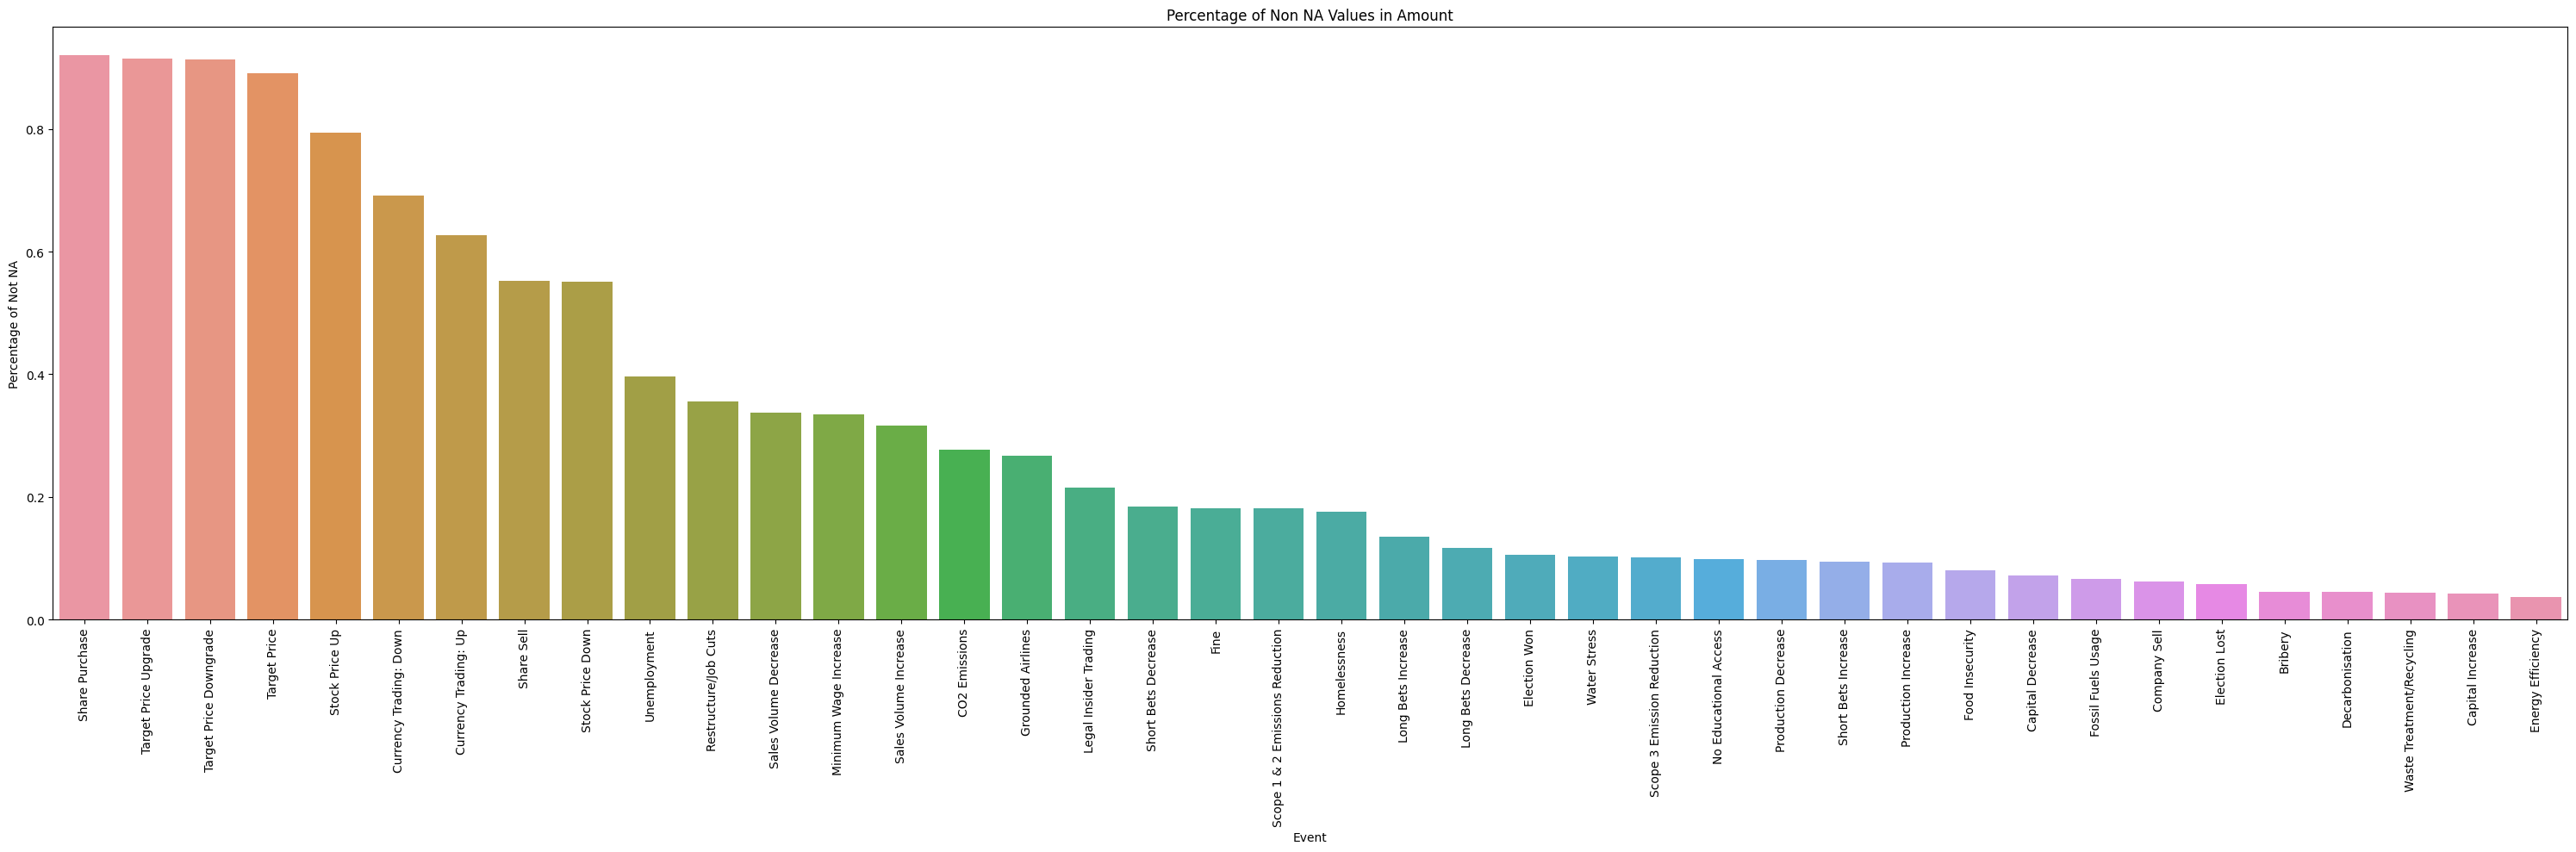

In [15]:
sorted_perc_notna_df = pd.DataFrame(sorted_perc_notna_40, columns = ['Event', 'Not_NA_Percentage'])
sorted_perc_notna_df

plt.figure(figsize=(30, 10))
sns.barplot(x='Event', y='Not_NA_Percentage', data=sorted_perc_notna_df)
plt.title('Percentage of Non NA Values in Amount')
plt.ylabel('Percentage of Not NA')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Percentage Not NA In Amount.png')
plt.show()
plt.close()

In [16]:
# same info
sorted_perc_notna_df

,Event,Not_NA_Percentage
0,Share Purchase,0.920377
1,Target Price Upgrade,0.914866
2,Target Price Downgrade,0.913597
3,Target Price,0.890920
4,Stock Price Up,0.793463
5,Currency Trading: Down,0.690921
6,Currency Trading: Up,0.626991
7,Share Sell,0.552612
8,Stock Price Down,0.551259
9,Unemployment,0.396088


In [17]:
# Summary Statistics for each event
amount_stats = {}
for name in event_data['event_name'].unique().tolist():
    event = event_data[event_data['event_name'] == name]
    amount = event['amount']
    stats = amount.describe()
    amount_stats[name] = stats

### Target Price
This part focus on 'Target Price' event

In [18]:
amount_stats['Target Price']

count    3.399770e+05
mean     6.736948e+06
std      3.927278e+09
min      0.000000e+00
25%      3.000000e+01
50%      7.406000e+01
75%      1.773100e+02
max      2.289899e+12
Name: amount, dtype: float64

In [19]:
target_price_amount = event_data[event_data['event_name'] == 'Target Price']['amount']
target_price_amount_freq = target_price_amount.value_counts()
sorted_target_price_amount_freq = target_price_amount_freq.sort_values(ascending=False)
sorted_target_price_amount_freq

amount
50.00     2075
35.00     1907
17.00     1645
205.27    1612
15.00     1590
          ... 
62.70        1
629.26       1
345.65       1
5.18         1
34.37        1
Name: count, Length: 9677, dtype: int64

This is the distribution of amount values for 'Target Price' event

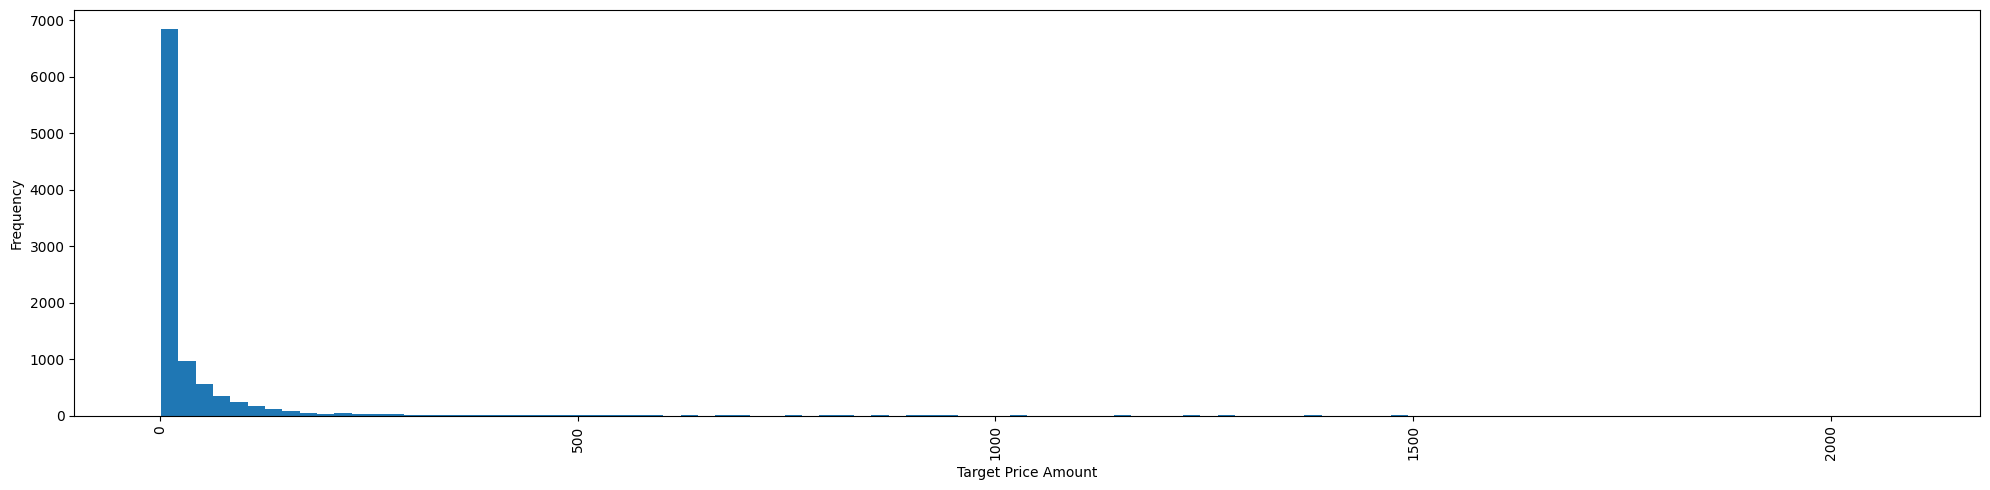

In [20]:
plt.figure(figsize=(20, 5))
plt.hist(sorted_target_price_amount_freq, bins=100)
plt.xlabel('Target Price Amount')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()

### Target Price Upgrade
This part focus on 'Target Price Upgrade' event

In [21]:
amount_stats['Target Price Upgrade']

count    6.090090e+05
mean     2.559907e+02
std      1.654045e+04
min      0.000000e+00
25%      3.900000e+01
50%      9.000000e+01
75%      1.860000e+02
max      7.378000e+06
Name: amount, dtype: float64

In [22]:
target_price_upgrade_amount = event_data[event_data['event_name'] == 'Target Price Upgrade']['amount']
target_price_upgrade_amount_freq = target_price_upgrade_amount.value_counts()
sorted_target_price_upgrade_amount_freq = target_price_upgrade_amount_freq.sort_values(ascending=False)
sorted_target_price_upgrade_amount_freq

amount
60.00     6216
80.00     6051
40.00     5464
20.00     5257
95.00     5243
          ... 
254.71       1
31.47        1
0.00         1
42.40        1
171.40       1
Name: count, Length: 1698, dtype: int64

This is the distribution of amount values for 'Target Price Upgrade' event

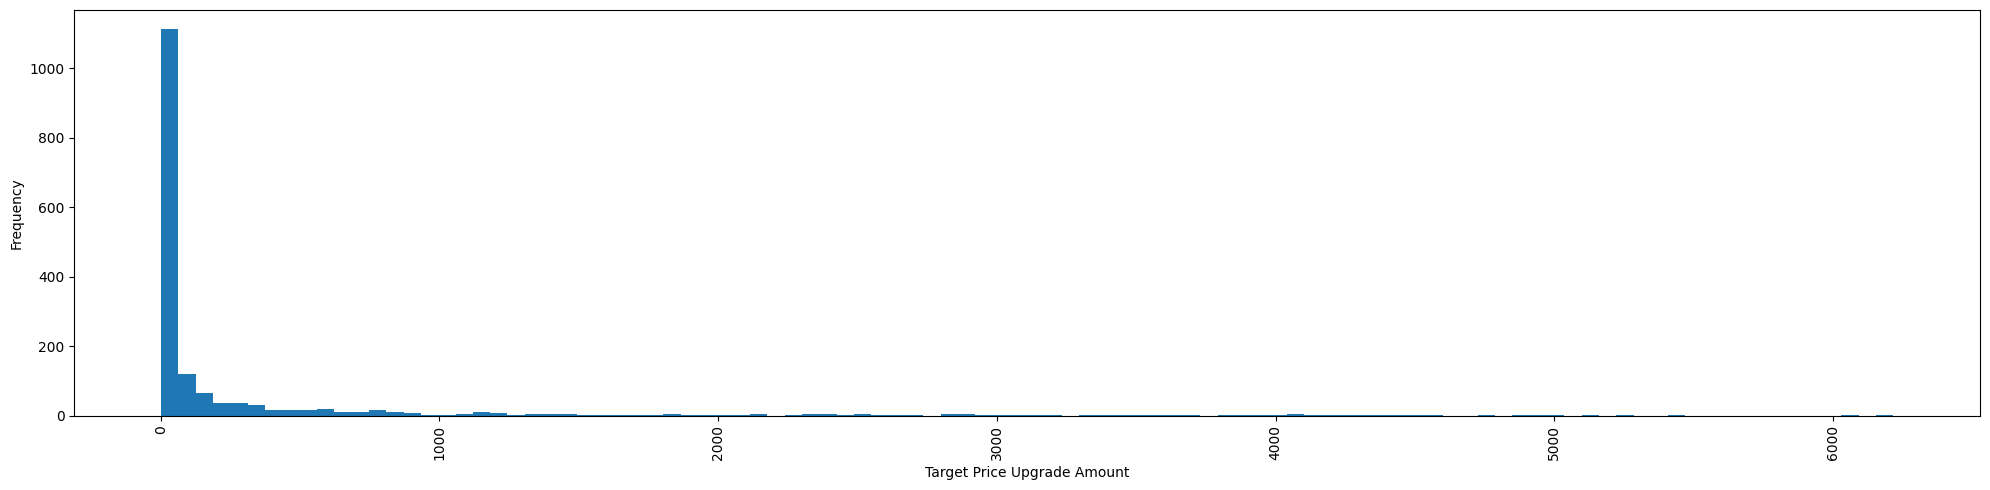

In [23]:
plt.figure(figsize=(20, 5))
plt.hist(sorted_target_price_upgrade_amount_freq, bins=100)
plt.xlabel('Target Price Upgrade Amount')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.close()

#### Target Price Upgrade for Selected Companies

In [24]:
entities = ['company:apple', 'company:nvidia', 'company:tesla_motors', 'company:sap', 'company:microsoft', 'company:starbucks', 'company:eyepoint_pharmaceuticals_inc']

output_dir = "target_price_upgrade"
for company in entities:
    target_price_upgrade_investigation = event_data[event_data['event_name'] == 'Target Price Upgrade']
    target_price_upgrade_investigation = target_price_upgrade_investigation[target_price_upgrade_investigation['event_participant_role'] == 2]
    target_price_upgrade_investigation = target_price_upgrade_investigation[target_price_upgrade_investigation['event_participant_id'] == company]
    target_price_upgrade_investigation = target_price_upgrade_investigation[target_price_upgrade_investigation['amount'].notna()]

    fig, ax = plt.subplots(1,1, figsize=(12,7))
    ax.scatter(target_price_upgrade_investigation['news_publish_time'], target_price_upgrade_investigation['amount'], alpha=0.2)
    plt.xticks(rotation=90)
    plt.xlabel('Time')
    plt.ylabel('Target Price Upgrade')
    plt.title(company)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f'{company.replace("/", "_")}.png'))
    plt.close()


KeyboardInterrupt: 

##### target_price_upgrade_df

In [ ]:
entities = ['company:apple', 'company:nvidia', 'company:tesla_motors', 'company:sap', 'company:microsoft', 'company:starbucks', 'company:eyepoint_pharmaceuticals_inc']
cols = ['Name', 'Time', 'Amount', 'Factuality', 'Temporality']
target_price_upgrade_df = []

In [ ]:
for company in entities:
    target_price_upgrade_investigation = event_data[event_data['event_name'] == 'Target Price Upgrade']
    target_price_upgrade_investigation = target_price_upgrade_investigation[target_price_upgrade_investigation['event_participant_id'] == company]
    target_price_upgrade = target_price_upgrade_investigation[['event_participant_id', 'news_publish_time', 'timestamp', 'amount', 'factuality', 'temporality']]
    target_price_upgrade_df.append(target_price_upgrade)

target_price_upgrade_df = pd.concat(target_price_upgrade_df)
target_price_upgrade_df

,event_participant_id,news_publish_time,timestamp,amount,factuality,temporality
13994342,company:apple,2024-03-01 11:25:00,1709288700,223.0,0-fact,0-past
13994343,company:apple,2024-03-01 10:03:00,1709283780,225.0,0-fact,0-past
13994344,company:apple,2024-03-02 10:56:00,1709373360,200.0,0-fact,0-past
13994345,company:apple,2024-03-03 10:49:06,1709459346,225.0,0-fact,0-past
13994346,company:apple,2024-03-05 10:57:17,1709632637,210.0,0-fact,0-past
...,...,...,...,...,...,...
7920414,company:eyepoint_pharmaceuticals_inc,2024-03-24 18:45:00,1711302300,30.0,0-fact,0-past
7920415,company:eyepoint_pharmaceuticals_inc,2024-03-25 09:55:16,1711356916,30.0,0-fact,0-past
7920416,company:eyepoint_pharmaceuticals_inc,2024-03-25 09:55:00,1711356900,30.0,0-fact,0-past
13985162,company:eyepoint_pharmaceuticals_inc,2024-03-19 20:36:00,1710876960,30.0,0-fact,0-past


##### Linear Regressions for 'Target Price Upgrade' for Selected Companies

In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression

Below generated scatter plots and regression lines for each company and saved into file

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


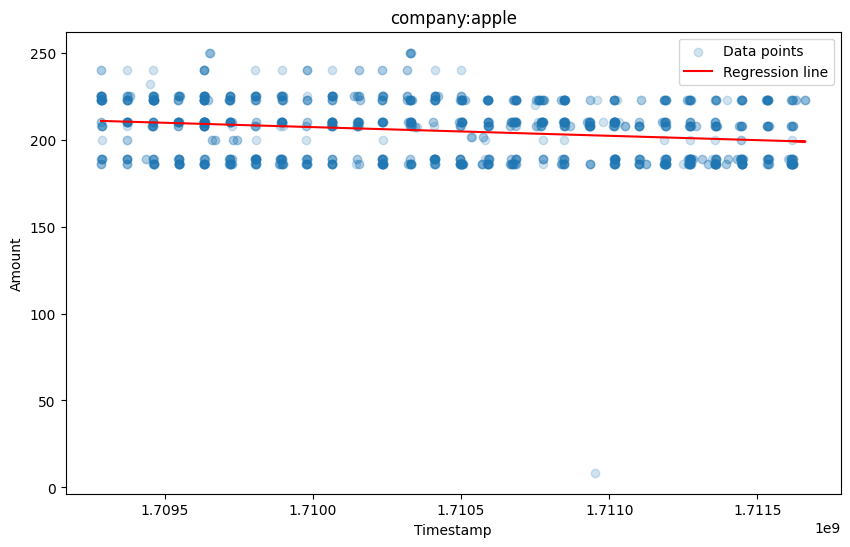

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


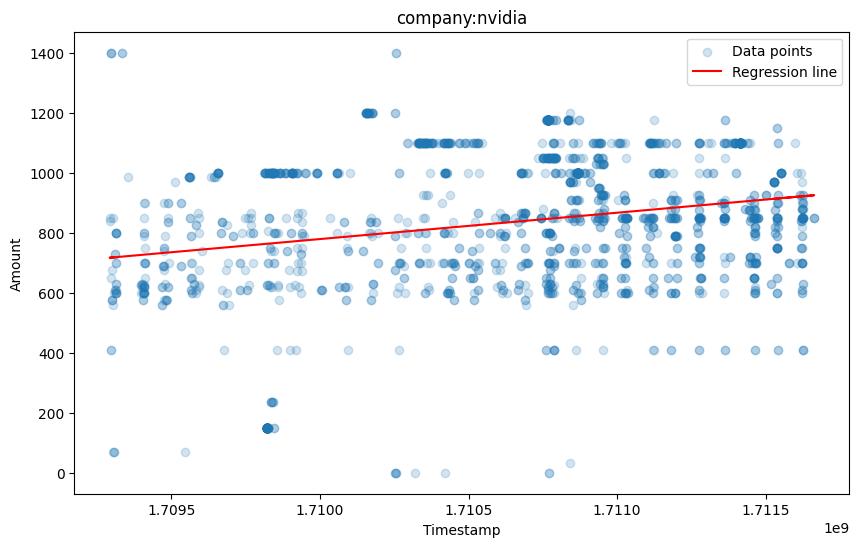

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


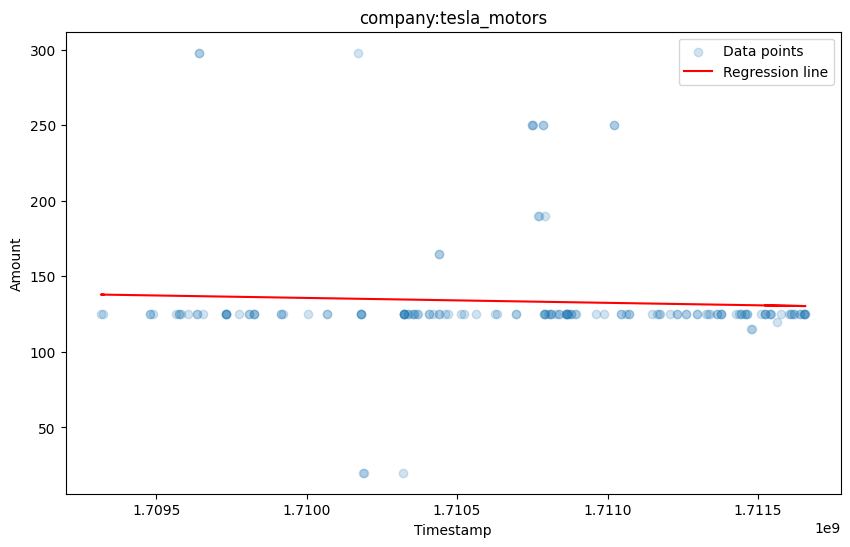

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


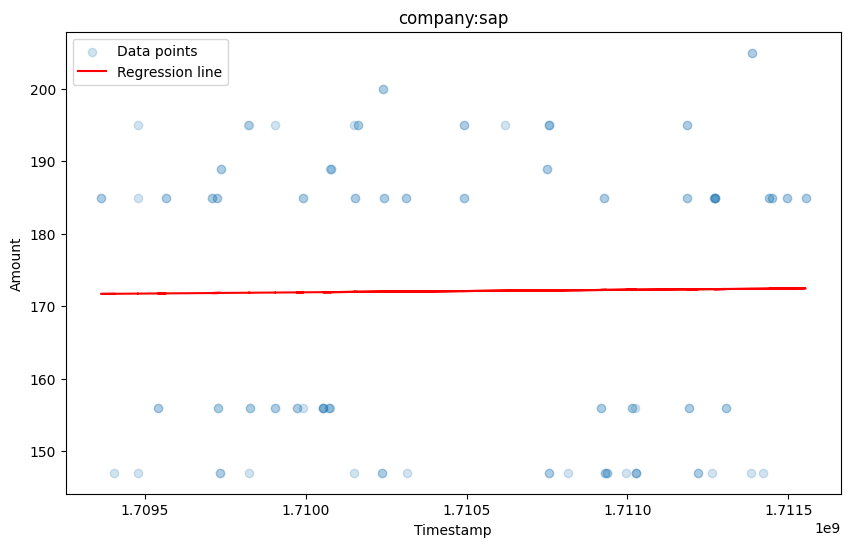

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


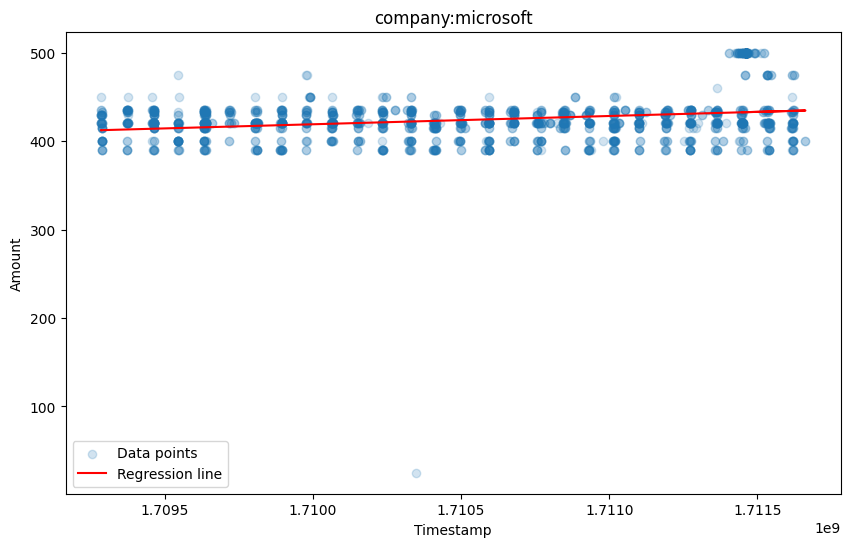

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


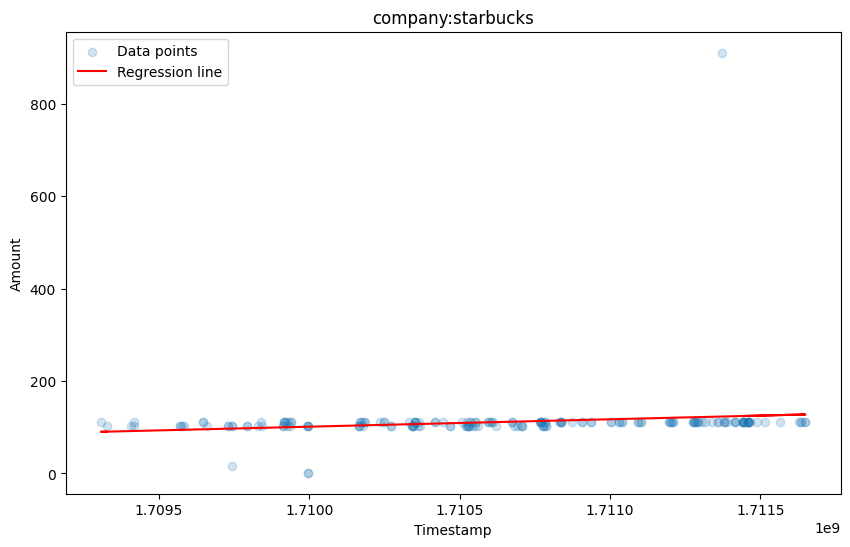

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_56801/274420863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amounts[2] = np.nan


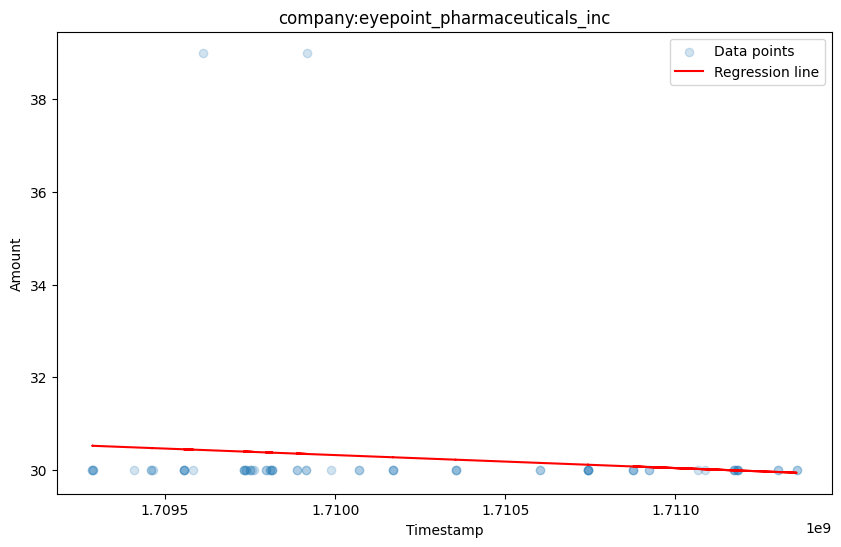

In [ ]:
linear_reg = []

for company in entities :
    timestamps = target_price_upgrade_df[target_price_upgrade_df['event_participant_id'] == company]['timestamp']
    amounts = target_price_upgrade_df[target_price_upgrade_df['event_participant_id'] == company]['amount']

    # only want non na pairs
    amounts[2] = np.nan
    data = pd.DataFrame({
        'timestamp': timestamps,
        'amount': amounts
    })
    data = data.dropna(subset=['amount'])

    X = data['timestamp'].values.reshape(-1, 1)
    y = data['amount'].values

    # fit the model
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, label='Data points', alpha=0.2)
    plt.plot(X, y_pred, color='red', label='Regression line')
    plt.xlabel('Timestamp')
    plt.ylabel('Amount')
    plt.title(company)
    plt.legend()
    plt.show()

    # slope & intercept values
    slope = model.coef_[0]
    intercept = model.intercept_
    new_row = {'Company': company, 'Slope': slope, 'Intercept': intercept}
    linear_reg.append(new_row)

Below is the slope and intercept calculated for each company

In [ ]:
linear_reg

[{'Company': 'company:apple',
  'Slope': -4.991041684487915e-06,
  'Intercept': 8741.895137659885},
 {'Company': 'company:nvidia',
  'Slope': 8.774082262946232e-05,
  'Intercept': -149257.49600760054},
 {'Company': 'company:tesla_motors',
  'Slope': -3.250685528581053e-06,
  'Intercept': 5694.368447530571},
 {'Company': 'company:sap',
  'Slope': 3.4753345776151267e-07,
  'Intercept': -422.3661005221295},
 {'Company': 'company:microsoft',
  'Slope': 9.35771080001758e-06,
  'Intercept': -15582.597195660746},
 {'Company': 'company:starbucks',
  'Slope': 1.6005911147473703e-05,
  'Intercept': -27268.938330265002},
 {'Company': 'company:eyepoint_pharmaceuticals_inc',
  'Slope': -2.8055798040438507e-07,
  'Intercept': 510.0761609158239}]

### Target Price Downgrade

In [ ]:
amount_stats['Target Price Downgrade']

count    288652.000000
mean        297.816969
std        8275.496969
min           0.040000
25%          24.000000
50%          62.000000
75%         136.000000
max      435000.000000
Name: amount, dtype: float64

In [ ]:
target_price_downgrade_amount = event_data[event_data['event_name'] == 'Target Price Downgrade']['amount']
target_price_downgrade_amount_freq = target_price_downgrade_amount.value_counts()
sorted_target_price_downgrade_amount_freq = target_price_downgrade_amount_freq.sort_values(ascending=False)
sorted_target_price_downgrade_amount_freq

amount
20.000       4281
23.000       3366
60.000       3341
40.000       3296
50.000       3278
             ... 
25.600          1
30.002          1
10900.000       1
18.400          1
32.750          1
Name: count, Length: 1264, dtype: int64

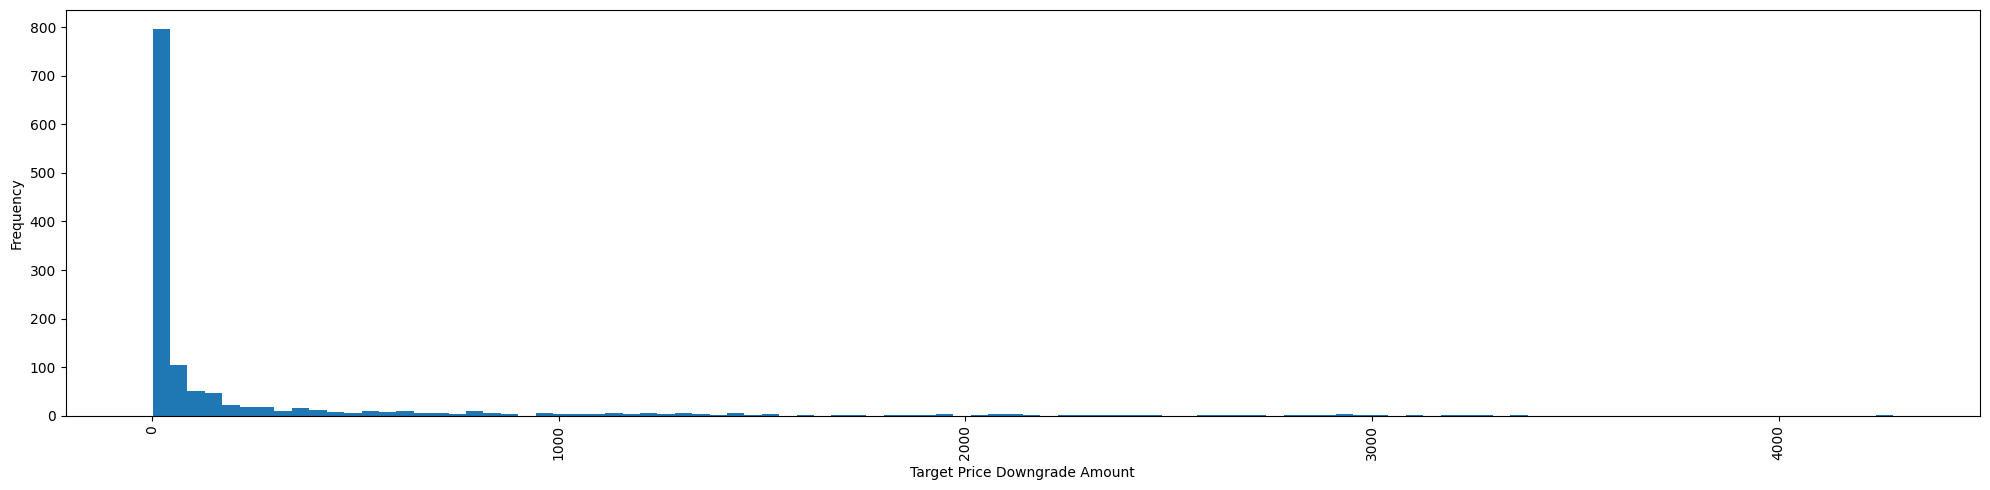

In [ ]:
plt.figure(figsize=(20,5))
plt.hist(sorted_target_price_downgrade_amount_freq, bins=100)
plt.xlabel('Target Price Downgrade Amount')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()

## g) Participant Role Distribution
Frequency of role being 0, 1, 2, 3, 4 for each event

In [ ]:
par_role_dist = {}

for event in event_data['event_name'].unique().tolist():
    data_tmp = event_data[event_data['event_name'] == event]
    result = data_tmp[['news_publish_time', 'event_participant_role']].groupby('event_participant_role').count()
    par_role_dist[event] = result
    par_role_dist[event]

In [ ]:
table2 = PrettyTable()
table2.field_names = ['Event Name', 'Role']
for event_name, role in par_role_dist.items():
    table2.add_row([event_name, role])
table2.align['Role'] = 'r'  # 'r' for right alignment
print(table2)

+------------------------------------+-------------------------------------------+
|             Event Name             |                                      Role |
+------------------------------------+-------------------------------------------+
|           Stock Price Up           |                         news_publish_time |
|                                    | event_participant_role                    |
|                                    | 0                                   95491 |
|                                    | 1                                 1193867 |
|           Share Purchase           |                         news_publish_time |
|                                    | event_participant_role                    |
|                                    | 0                                   81606 |
|                                    | 1                                 2150126 |
|                                    | 2                                  727057 |
|   